17464789/17464789 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
Training Samples: (25000, 200)
Testing Samples: (25000, 200)


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/embedding.py:100: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(



Model Architecture Summary


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding (Embedding)           │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ simple_rnn (SimpleRNN)          │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

Epoch 1/5
313/313 ━━━━━━━━━━━━━━━━━━━━ 12s 24ms/step - accuracy: 0.6122 - loss: 0.6447 - val_accuracy: 0.6708 - val_loss: 0.5955
Epoch 2/5
313/313 ━━━━━━━━━━━━━━━━━━━━ 6s 18ms/step - accuracy: 0.8478 - loss: 0.3634 - val_accuracy: 0.8222 - val_loss: 0.4307
Epoch 3/5
313/313 ━━━━━━━━━━━━━━━━━━━━ 6s 18ms/step - accuracy: 0.9492 - loss: 0.1421 - val_accuracy: 0.7920 - val_loss: 0.5399
Epoch 4/5
313/313 ━━━━━━━━━━━━━━━━━━━━ 6s 18ms/step - accuracy: 0.9908 - loss: 0.0366 - val_accuracy: 0.7726 - val_loss: 0.7217
Epoch 5/5
313/313 ━━━━━━━━━━━━━━━━━━━━ 6s 18ms/step - accuracy: 0.9962 - loss: 0.0156 - val_accuracy: 0.7918 - val_loss: 0.7364


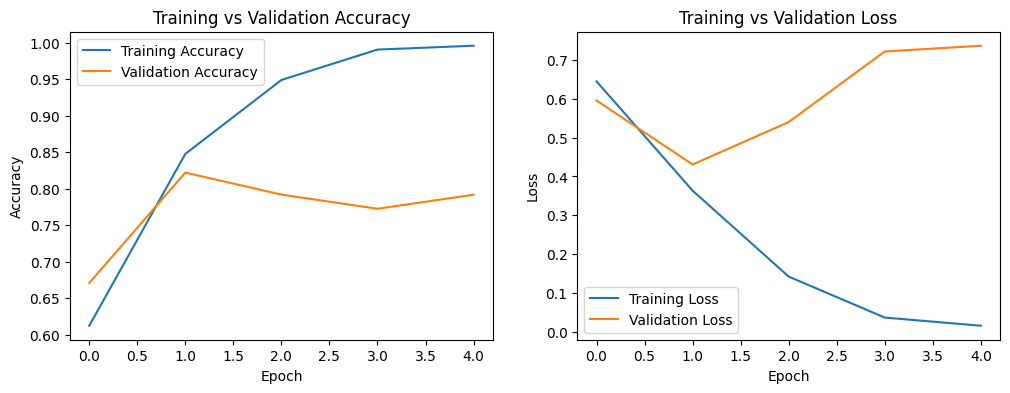

782/782 ━━━━━━━━━━━━━━━━━━━━ 4s 5ms/step - accuracy: 0.7867 - loss: 0.7556

Model Evaluation
Test Loss: 0.7556151747703552
Test Accuracy: 0.7867199778556824
782/782 ━━━━━━━━━━━━━━━━━━━━ 4s 5ms/step


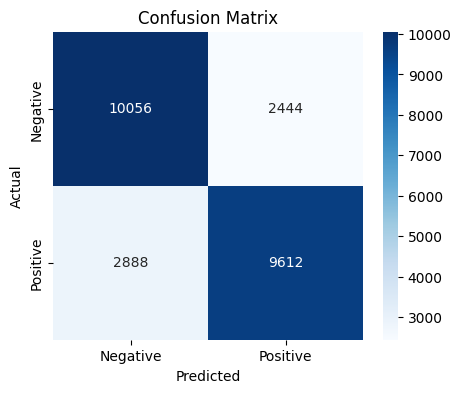


Classification Report
              precision    recall  f1-score   support

           0       0.78      0.80      0.79     12500
           1       0.80      0.77      0.78     12500

    accuracy                           0.79     25000
   macro avg       0.79      0.79      0.79     25000
weighted avg       0.79      0.79      0.79     25000


Sample Prediction Interpretation

Review 1
Actual Sentiment : Negative
Predicted Sentiment: Negative
Prediction Confidence: 0.111
----------------------------------------
Review 2
Actual Sentiment : Positive
Predicted Sentiment: Positive
Prediction Confidence: 0.985
----------------------------------------
Review 3
Actual Sentiment : Positive
Predicted Sentiment: Negative
Prediction Confidence: 0.217
----------------------------------------
Review 4
Actual Sentiment : Negative
Predicted Sentiment: Negative
Prediction Confidence: 0.213
----------------------------------------
Review 5
Actual Sentiment : Positive
Predicted Sentiment: Positive


In [1]:
# -----------------------------------------------------------
# Step 1: Import Required Libraries
# -----------------------------------------------------------
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from tensorflow.keras.datasets import imdb
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, SimpleRNN, Dense
from sklearn.metrics import confusion_matrix, classification_report
# -----------------------------------------------------------
# Step 2: Load Dataset
# -----------------------------------------------------------
vocab_size = 10000
max_len = 200
(X_train, y_train), (X_test, y_test) = imdb.load_data(num_words=vocab_size)
# Pad sequences
X_train = pad_sequences(X_train, maxlen=max_len)
X_test = pad_sequences(X_test, maxlen=max_len)
print("Training Samples:", X_train.shape)
print("Testing Samples:", X_test.shape)
# -----------------------------------------------------------
# Step 3: Build RNN Model
# -----------------------------------------------------------
model = Sequential([
Embedding(vocab_size, 128, input_length=max_len),
SimpleRNN(64),
Dense(1, activation='sigmoid')
])
model.compile(
optimizer='adam',
loss='binary_crossentropy',
metrics=['accuracy']
)
print("\nModel Architecture Summary")
model.summary()
# -----------------------------------------------------------
# Step 4: Train Model
# -----------------------------------------------------------
history = model.fit(
X_train,
y_train,
epochs=5,
batch_size=64,
validation_split=0.2
)
# -----------------------------------------------------------
# Step 5: Training Analysis (Visualization)
# -----------------------------------------------------------
plt.figure(figsize=(12,4))
# Accuracy Curve
plt.subplot(1,2,1)
plt.plot(history.history['accuracy'], label='Training Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.title("Training vs Validation Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()
# Loss Curve
plt.subplot(1,2,2)
plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.title("Training vs Validation Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.show()
# -----------------------------------------------------------
# Step 6: Evaluate Model
# -----------------------------------------------------------
test_loss, test_acc = model.evaluate(X_test, y_test)
print("\nModel Evaluation")
print("Test Loss:", test_loss)
print("Test Accuracy:", test_acc)
# -----------------------------------------------------------
# Step 7: Predictions
# -----------------------------------------------------------
predictions = model.predict(X_test)
# Convert probabilities to binary predictions
y_pred = (predictions > 0.5).astype(int)
# -----------------------------------------------------------
# Step 8: Confusion Matrix
# -----------------------------------------------------------
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(5,4))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
xticklabels=["Negative","Positive"],
yticklabels=["Negative","Positive"])
plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()
# -----------------------------------------------------------
# Step 9: Classification Report
# -----------------------------------------------------------
print("\nClassification Report")
print(classification_report(y_test, y_pred))
# -----------------------------------------------------------
# Step 10: Interpretation of Sample Predictions
# -----------------------------------------------------------
print("\nSample Prediction Interpretation\n")
for i in range(5):
  probability = predictions[i][0]
  predicted_sentiment = "Positive" if probability > 0.5 else "Negative"
  actual_sentiment = "Positive" if y_test[i] == 1 else "Negative"
  print(f"Review {i+1}")
  print("Actual Sentiment :", actual_sentiment)
  print("Predicted Sentiment:", predicted_sentiment)
  print("Prediction Confidence:", round(probability,3))
  print("-"*40)
